In [ ]:
# Uncomment and run this cell once to install required libraries
# !pip install ultralytics opencv-python matplotlib numpy pillow tqdm pillow-heif

In [ ]:
import sys, os

IN_COLAB = "google.colab" in sys.modules or "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # ← Change this to the folder in your Drive that contains the notebook + dataset
    PROJECT_PATH = "MyDrive/Obsedian Vaults/IAU/ImageProssecing/Project Code/Dates-Fruits-Image"

    os.chdir(f"/content/drive/{PROJECT_PATH}")
    print("Running in Colab. Working directory set to:", os.getcwd())
else:
    print("Running locally. No changes to working directory.")

Extract the dataset zip file into a local folder.

Count images per class and display a bar chart showing the class distribution.

In [ ]:
# Download the dataset manually:
# 1. Go to https://zenodo.org/records/4639543
# 2. Click "Download all" to download the zip file
# 3. Move the downloaded zip file to the same folder as this notebook
# 4. Run this cell to extract it

import zipfile
import os

zip_path = "4639543.zip"

os.makedirs("date_fruit_dataset", exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("date_fruit_dataset")

print("Extraction complete!")

Total classes : 10
Total images  : 528

  IMG                  28 images
  Muraaya              100 images
  NbotAli              95 images
  Sawr                 7 images
  SequeeIRAQ           69 images
  Shagra               24 images
  Skari                65 images
  masyihia             31 images
  sequee               47 images
  skri_magrosh         62 images


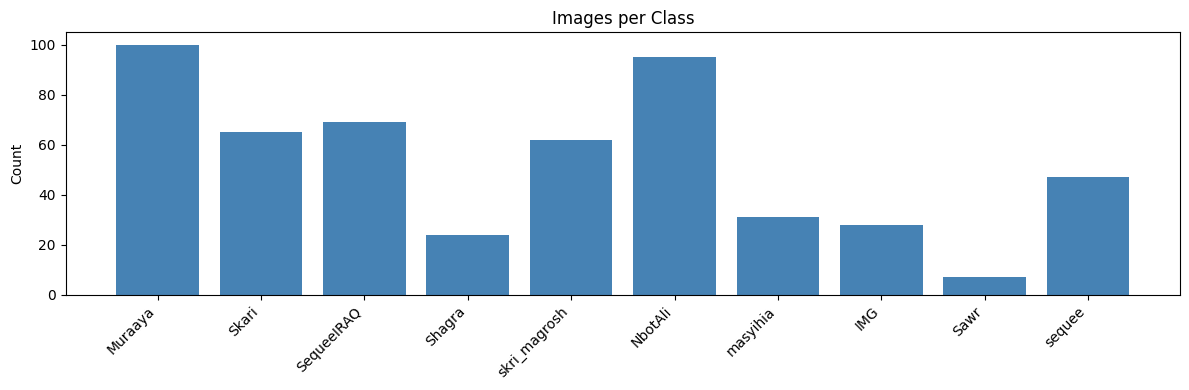

In [2]:
import os
import matplotlib.pyplot as plt

dataset_dir = "date_fruit_dataset"

def get_class(filename):
    name = os.path.splitext(filename)[0]
    for sep in ["-", "_"]:
        if sep in name:
            prefix, suffix = name.rsplit(sep, 1)
            if suffix.isdigit():
                return prefix
    return name

class_images = {}
for f in os.listdir(dataset_dir):
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".heic")):
        cls = get_class(f)
        class_images.setdefault(cls, []).append(f)

print(f"Total classes : {len(class_images)}")
print(f"Total images  : {sum(len(v) for v in class_images.values())}")
print()
for cls, imgs in sorted(class_images.items()):
    print(f"  {cls:<20} {len(imgs)} images")

plt.figure(figsize=(12, 4))
plt.bar(class_images.keys(), [len(v) for v in class_images.values()], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Images per Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Display one sample image per class in a grid.

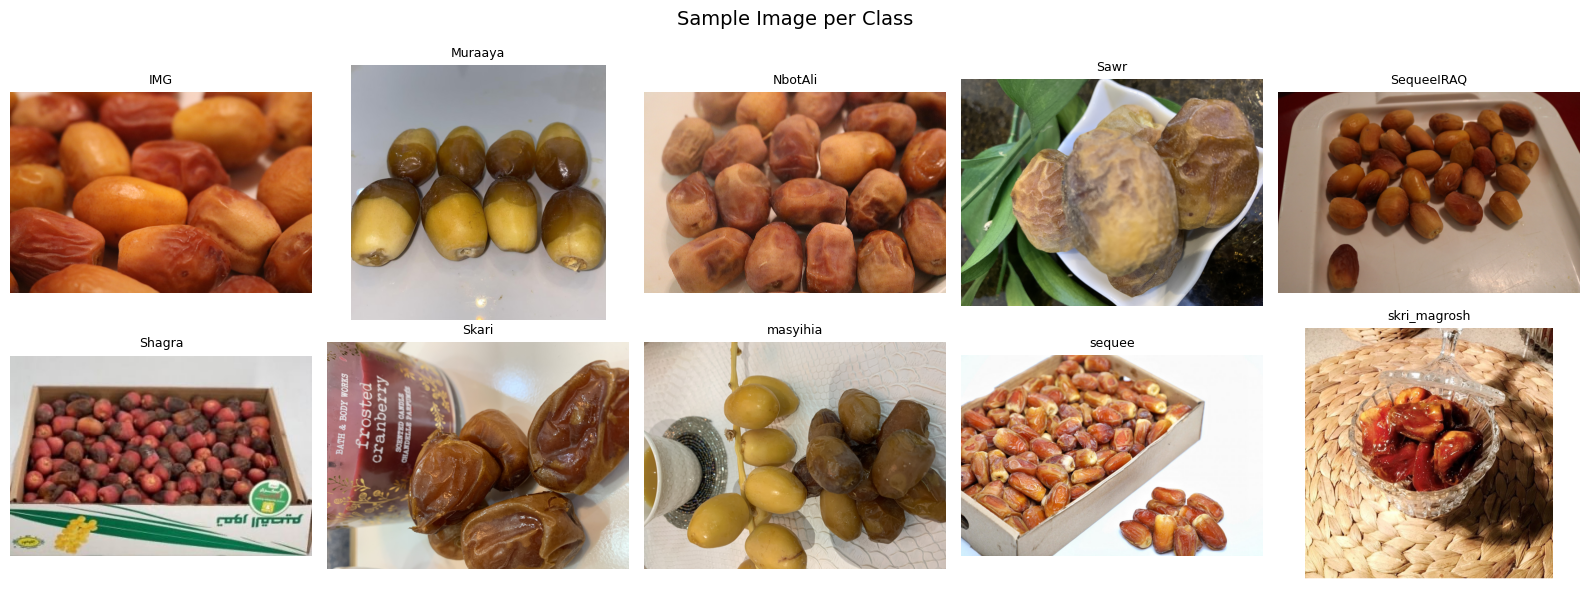

In [3]:
import random
from PIL import Image
from pillow_heif import register_heif_opener

register_heif_opener()

classes = sorted(class_images.keys())
cols = 5
rows = (len(classes) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
axes = axes.flatten()

for i, cls in enumerate(classes):
    img_file = random.choice(class_images[cls])
    img = Image.open(os.path.join(dataset_dir, img_file)).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis("off")

for j in range(len(classes), len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Image per Class", fontsize=14)
plt.tight_layout()
plt.show()

Convert all `.heic` images to `.jpg` and save them back into `date_fruit_dataset/`.

In [ ]:
from PIL import Image
from pillow_heif import register_heif_opener
from tqdm import tqdm

register_heif_opener()

heic_files = [f for f in os.listdir(dataset_dir) if f.lower().endswith(".heic")]

for filename in tqdm(heic_files, desc="Converting HEIC"):
    src = os.path.join(dataset_dir, filename)
    dst = os.path.join(dataset_dir, os.path.splitext(filename)[0] + ".jpg")
    Image.open(src).convert("RGB").save(dst, "JPEG")
    os.remove(src)

# refresh class_images after conversion
class_images = {}
for f in os.listdir(dataset_dir):
    if f.lower().endswith((".jpg", ".jpeg", ".png")):
        cls = get_class(f)
        class_images.setdefault(cls, []).append(f)

print(f"Converted {len(heic_files)} HEIC files. Total images now: {sum(len(v) for v in class_images.values())}")

Resize all images to 224×224 and save them into `processed/`.

In [ ]:
TARGET_SIZE = (224, 224)
processed_dir = "processed"
os.makedirs(processed_dir, exist_ok=True)

all_images = [f for f in os.listdir(dataset_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

for filename in tqdm(all_images, desc="Resizing"):
    src = os.path.join(dataset_dir, filename)
    dst = os.path.join(processed_dir, os.path.splitext(filename)[0] + ".jpg")
    img = Image.open(src).convert("RGB").resize(TARGET_SIZE, Image.LANCZOS)
    img.save(dst, "JPEG")

print(f"Saved {len(all_images)} resized images to '{processed_dir}/'")

## Background Removal with GrabCut

Use OpenCV's GrabCut algorithm to separate each date fruit from its background.  
GrabCut works by assuming everything near the image edges is background and everything in the center is foreground, then refines the boundary iteratively.  
The cleaned images are saved into `segmented/`.

In [ ]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

processed_dir = "processed"

BORDER = 10          # pixels from edge treated as background
SAMPLE_SIZE = 6      # ← change to test more/fewer images
MIN_FG_RATIO = 0.10  # if GrabCut finds less than 10% foreground, it probably failed

def grabcut_segment(img_bgr):
    """
    Remove the background using GrabCut.
    Returns (cleaned_image, success_flag).
    If GrabCut produces an implausibly small foreground mask,
    we fall back to returning the original image unchanged.
    """
    h, w = img_bgr.shape[:2]

    # Step 1: Rectangle — pixels outside this are assumed background
    rect = (BORDER, BORDER, w - BORDER * 2, h - BORDER * 2)

    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    mask = np.zeros((h, w), np.uint8)

    # Step 2: Run GrabCut (5 iterations)
    cv2.grabCut(img_bgr, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)

    # Step 3: Build foreground mask (keep definite + probable foreground)
    fg_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 255, 0).astype(np.uint8)

    # Step 4: Clean up noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, kernel)
    fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN,  kernel)

    # Step 5: Sanity check — did we actually find a reasonable foreground?
    fg_ratio = (fg_mask > 0).sum() / (h * w)
    if fg_ratio < MIN_FG_RATIO:
        # GrabCut failed (e.g. cluttered background fills the whole frame)
        return img_bgr.copy(), False

    # Step 6: Paint background white
    result = img_bgr.copy()
    result[fg_mask == 0] = [255, 255, 255]
    return result, True

# ── Sample and plot ──
all_images = [f for f in os.listdir(processed_dir) if f.lower().endswith(".jpg")]
samples = random.sample(all_images, min(SAMPLE_SIZE, len(all_images)))

fig, axes = plt.subplots(2, SAMPLE_SIZE, figsize=(SAMPLE_SIZE * 3, 6))

for col, filename in enumerate(samples):
    path = os.path.join(processed_dir, filename)
    img_bgr = cv2.imread(path)
    seg_bgr, success = grabcut_segment(img_bgr)

    orig_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    seg_rgb  = cv2.cvtColor(seg_bgr, cv2.COLOR_BGR2RGB)

    axes[0, col].imshow(orig_rgb)
    axes[0, col].set_title(filename[:15], fontsize=7)
    axes[0, col].axis("off")

    axes[1, col].imshow(seg_rgb)
    label = "segmented" if success else "fallback (original)"
    axes[1, col].set_title(label, fontsize=7, color="green" if success else "red")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("GrabCut",  fontsize=10)

plt.suptitle(f"GrabCut Background Removal — {SAMPLE_SIZE} random samples", fontsize=12)
plt.tight_layout()
plt.show()

## Extract Feature Vectors → `features.csv`

For each segmented image, we compute a **color histogram** — counting how often each color shade appears across the Red, Green, and Blue channels.  
Using 64 bins per channel gives 192 numbers per image, which together describe its color signature.  
These vectors are saved to `features.csv` and used for similarity search in the next step.

In [ ]:
import cv2
import numpy as np
import os
import pandas as pd
from tqdm import tqdm

segmented_dir = "segmented"
BINS = 64  # bins per colour channel  →  64 × 3 = 192 features total

def extract_features(img_path):
    """Return a normalised colour histogram for one image (192 values)."""
    img = cv2.imread(img_path)                      # load as BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)      # convert to RGB

    features = []
    for channel in range(3):                        # R, G, B
        hist = cv2.calcHist([img], [channel], None, [BINS], [0, 256])
        hist = hist.flatten() / hist.sum()          # normalise so values sum to 1
        features.extend(hist)

    return features

# Derive the class name from the filename (e.g. "Sukkari-001.jpg" → "Sukkari")
def get_class(filename):
    name = os.path.splitext(filename)[0]
    for sep in ["-", "_"]:
        if sep in name:
            prefix, suffix = name.rsplit(sep, 1)
            if suffix.isdigit():
                return prefix
    return name

all_images = sorted(f for f in os.listdir(segmented_dir) if f.lower().endswith(".jpg"))

rows = []
for filename in tqdm(all_images, desc="Extracting features"):
    path = os.path.join(segmented_dir, filename)
    feat = extract_features(path)
    rows.append([filename, get_class(filename)] + feat)

col_names = ["filename", "class"] + [f"f{i}" for i in range(BINS * 3)]
df = pd.DataFrame(rows, columns=col_names)
df.to_csv("features.csv", index=False)

print(f"Saved features.csv  —  {len(df)} images  ×  {BINS * 3} features")

Pick a random image, compute cosine similarity against every other image using `features.csv`, and display the top 5 most similar images.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

df = pd.read_csv("features.csv")

feature_cols = [c for c in df.columns if c not in ("filename", "class")]
vectors = df[feature_cols].values.astype(np.float32)

# Normalize all rows for cosine similarity
norms = np.linalg.norm(vectors, axis=1, keepdims=True)
norms = np.where(norms == 0, 1e-10, norms)
normed = vectors / norms

# Pick a random query image
query_idx = random.randint(0, len(df) - 1)
query_row = df.iloc[query_idx]
query_vec = normed[query_idx]

# Cosine similarity against all images
sims = normed @ query_vec

# Top 5 most similar (excluding the query itself)
sims[query_idx] = -1
top5_idx = np.argsort(sims)[::-1][:5]

# Display query + top 5
processed_dir = "processed"
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

def load_img(filename):
    path = os.path.join(processed_dir, os.path.splitext(filename)[0] + ".jpg")
    return Image.open(path).convert("RGB")

axes[0].imshow(load_img(query_row["filename"]))
axes[0].set_title(f"QUERY\n{query_row['class']}", fontsize=8, color="red")
axes[0].axis("off")

for rank, idx in enumerate(top5_idx, start=1):
    row = df.iloc[idx]
    axes[rank].imshow(load_img(row["filename"]))
    axes[rank].set_title(f"#{rank}  sim={sims[idx]:.3f}\n{row['class']}", fontsize=8)
    axes[rank].axis("off")

plt.suptitle(f"Query: {query_row['filename']}  —  Top 5 Most Similar", fontsize=10)
plt.tight_layout()
plt.show()